# Emojis classification
## Imports
### Libraries

In [53]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


First, we unzip the data file on Google Colab.

In [54]:
#!unzip -q data.zip -d /content/

In [55]:
#!ls -lh data.zip
#!file data.zip

Then, we import the necessary librairies.

In [56]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    BatchNormalization, Conv2D, Dense, Dropout, GlobalAveragePooling2D, Input, MaxPooling2D,
    RandomFlip, RandomTranslation, RandomZoom, ReLU,
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

### Data

In [57]:
DATA_DIR = Path("/content/drive/MyDrive/data")  # On Colab, point this to the folder holding train/, test/ and train_labels.csv
IMG_SIZE = 72

def load_image(img_file: Path) -> np.ndarray:
    # Images mix RGBA and palette PNGs: composite onto a white background to get a uniform RGB array
    img = Image.open(img_file).convert("RGBA")
    background = Image.new("RGBA", img.size, (255, 255, 255, 255))
    img = Image.alpha_composite(background, img).convert("RGB")
    # Images come in several sizes (64 to 240 px, some non-square): pad to a white square, then resize
    side = max(img.size)
    square = Image.new("RGB", (side, side), (255, 255, 255))
    square.paste(img, ((side - img.width) // 2, (side - img.height) // 2))
    return np.array(square.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.LANCZOS))

def load_data(folder_path: Path):
    ids = []
    dataset = []
    for img_file in sorted(folder_path.iterdir()):
        if img_file.suffix != ".png":
            continue
        ids.append(img_file.stem)
        dataset.append(load_image(img_file))
    dataset_as_array = np.array(dataset)
    return dataset_as_array, ids

In [58]:
X_train, X_train_ids = load_data(DATA_DIR / "train")
X_test, X_test_ids = load_data(DATA_DIR / "test")

labels = pd.read_csv(DATA_DIR / "train_labels.csv", dtype={"Id": str}).set_index("Id")

# Filtrer X_train et X_train_ids pour ne garder que les IDs présents dans labels
valid_indices = [i for i, img_id in enumerate(X_train_ids) if img_id in labels.index]
X_train = X_train[valid_indices]
X_train_ids = [X_train_ids[i] for i in valid_indices]

y_train = labels.loc[X_train_ids, "Label"].to_numpy()

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (9879, 72, 72, 3)
y_train shape: (9879,)
X_test shape: (9879, 72, 72, 3)


In [59]:
# Vérification du matching entre les labels et les images chargées
missing_ids = labels.index.difference(X_train_ids)

print(f"Nombre total d'IDs uniques dans labels : {len(labels)}")
print(f"Nombre d'IDs uniques chargés et matchés : {len(set(X_train_ids) & set(labels.index))}")

if len(missing_ids) == 0:
    print("Toutes les images listées dans labels.csv ont été trouvées et matchées.")
else:
    print(f"Attention ! {len(missing_ids)} IDs présents dans labels.csv n'ont pas d'image correspondante dans le dossier train.")
    print("Exemples d'IDs manquants :", list(missing_ids[:5]))

Nombre total d'IDs uniques dans labels : 9879
Nombre d'IDs uniques chargés et matchés : 9879
Toutes les images listées dans labels.csv ont été trouvées et matchées.


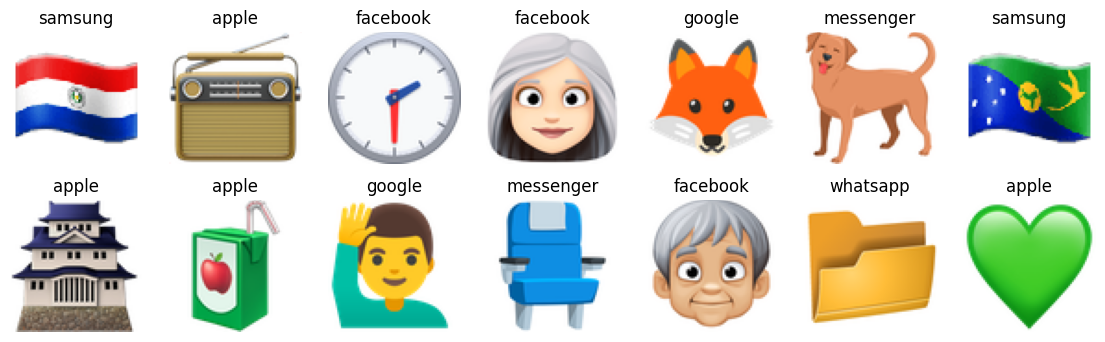

In [60]:
fig, axes = plt.subplots(2, 7, figsize=(14, 4))
for ax, img, label in zip(axes.flat, X_train, y_train):
    ax.imshow(img)
    ax.set_title(label)
    ax.axis("off")
plt.show()

### Preprocessing

In [61]:
# Normalize pixel values to [0, 1]
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

print(f"Normalized X_train shape: {X_train_norm.shape}")
print(f"Normalized X_test shape: {X_test_norm.shape}")

Normalized X_train shape: (9879, 72, 72, 3)
Normalized X_test shape: (9879, 72, 72, 3)


In [62]:
# Encode string labels as integers, then one-hot encode
classes = np.array(sorted(set(y_train)))
num_classes = len(classes)
y_train_int = np.searchsorted(classes, y_train)
y_train_cat = to_categorical(y_train_int, num_classes=num_classes)

print(f"Classes: {list(classes)}")
print(f"Categorical y_train shape: {y_train_cat.shape}")

Classes: [np.str_('apple'), np.str_('facebook'), np.str_('google'), np.str_('messenger'), np.str_('mozilla'), np.str_('samsung'), np.str_('whatsapp')]
Categorical y_train shape: (9879, 7)


In [63]:
# Hold out a fixed random 15% of the training set for validation
# (Keras' validation_split would always take the last 20% of the files, without shuffling)
rng = np.random.default_rng(0)
shuffled = rng.permutation(len(X_train_norm))
n_val = int(0.15 * len(X_train_norm))
val_idx, train_idx = shuffled[:n_val], shuffled[n_val:]

X_tr, y_tr = X_train_norm[train_idx], y_train_cat[train_idx]
X_val, y_val = X_train_norm[val_idx], y_train_cat[val_idx]

print(f"Train: {X_tr.shape}, validation: {X_val.shape}")

Train: (8398, 72, 72, 3), validation: (1481, 72, 72, 3)


## Model
### Model architecture

A plain LeNet (sigmoid activations, average pooling, Adam with lr=0.01) did not learn at all: about 20% validation accuracy, i.e. predicting the most common vendor. We use a deeper CNN instead:

- Data augmentation (training only): random shifts (±8%), zoom (±10%), horizontal flip
- 4 convolutional blocks with 32 → 64 → 128 → 256 filters. Each block is twice (3x3 convolution → batch normalization → ReLU), then 2x2 max pooling: 72 → 36 → 18 → 9 → 4 px
- Global average pooling: one value per filter (256)
- Dropout 30%
- Dense : 7 neurons, softmax

ReLU avoids the vanishing gradients of stacked sigmoids, batch normalization stabilizes training, and max pooling keeps the sharp details (outlines, highlights) that distinguish vendor styles.

In [64]:
tf.keras.utils.set_random_seed(42)

def conv_block(filters):
    layers = []
    for _ in range(2):
        layers += [
            Conv2D(filters, kernel_size=(3, 3), padding="same", use_bias=False),
            BatchNormalization(),
            ReLU(),
        ]
    return layers + [MaxPooling2D(pool_size=(2, 2))]

model = Sequential([
    Input(shape=X_train_norm.shape[1:]),

    # Augmentation layers are only active during training
    RandomTranslation(0.08, 0.08),
    RandomZoom(0.1),
    RandomFlip("horizontal"),

    *conv_block(32),
    *conv_block(64),
    *conv_block(128),
    *conv_block(256),

    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(num_classes, activation="softmax"),
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_translation_3            │ (None, 72, 72, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_3 (RandomZoom)      │ (None, 72, 72, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_3 (RandomFlip)      │ (None, 72, 72, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 72, 72, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 72, 72, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_24 (ReLU)                 │ (None, 72, 72, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 72, 72, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 72, 72, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_25 (ReLU)                 │ (None, 72, 72, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 36, 36, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 36, 36, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_26 (ReLU)                 │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 36, 36, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 36, 36, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_27 (ReLU)                 │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 18, 18, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_28 (ReLU)                 │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 18, 18, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 18, 18, 128)    │           51

 Total params: 1,176,935 (4.49 MB)

 Trainable params: 1,175,015 (4.48 MB)

 Non-trainable params: 1,920 (7.50 KB)

### Model training parameters

In [65]:
model.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    metrics=["accuracy"]
)

In [66]:
MODEL_PATH = "emoji_cnn.keras"

callbacks = [
    # Halve the learning rate when validation accuracy stalls for 3 epochs
    ReduceLROnPlateau(monitor="val_accuracy", factor=0.5, patience=3),
    # Stop when validation accuracy has not improved for 8 epochs
    EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True),
    # Save the best model so far, so predictions don't require retraining
    ModelCheckpoint(MODEL_PATH, monitor="val_accuracy", save_best_only=True),
]

history = model.fit(
    X_tr,
    y_tr,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
)

# Continue with the best epoch's weights
model = tf.keras.models.load_model(MODEL_PATH)

Epoch 1/40
132/132 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - accuracy: 0.2933 - loss: 1.8361 - val_accuracy: 0.1938 - val_loss: 2.3358 - learning_rate: 5.0000e-04
Epoch 2/40
132/132 ━━━━━━━━━━━━━━━━━━━━ 20s 76ms/step - accuracy: 0.4249 - loss: 1.4988 - val_accuracy: 0.1965 - val_loss: 2.4259 - learning_rate: 5.0000e-04
Epoch 3/40
132/132 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - accuracy: 0.5064 - loss: 1.3023 - val_accuracy: 0.3214 - val_loss: 1.9953 - learning_rate: 5.0000e-04
Epoch 4/40
132/132 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - accuracy: 0.5583 - loss: 1.1573 - val_accuracy: 0.3059 - val_loss: 2.4096 - learning_rate: 5.0000e-04
Epoch 5/40
132/132 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.6111 - loss: 1.0482 - val_accuracy: 0.2269 - val_loss: 4.6932 - learning_rate: 5.0000e-04
Epoch 6/40
132/132 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - accuracy: 0.6432 - loss: 0.9616 - val_accuracy: 0.2377 - val_loss: 5.1086 - learning_rate: 5.0000e-04
Epoch 7/40
132/132 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/ste

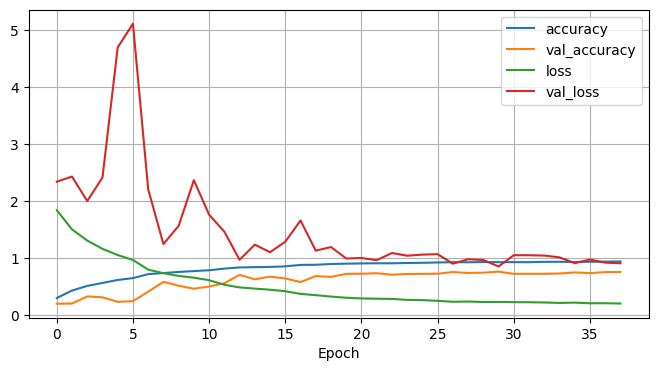

In [67]:
pd.DataFrame(history.history)[["accuracy", "val_accuracy", "loss", "val_loss"]].plot(figsize=(8, 4), grid=True)
plt.xlabel("Epoch")
plt.show()

In [68]:
# Per-vendor results on the validation set: rows are true vendors, columns are predictions
val_true = classes[np.argmax(y_val, axis=1)]
val_pred = classes[np.argmax(model.predict(X_val), axis=1)]

print(f"Validation accuracy: {np.mean(val_true == val_pred):.4f}")
confusion = pd.crosstab(val_true, val_pred, rownames=["true"], colnames=["predicted"])
confusion = confusion.reindex(index=classes, columns=classes, fill_value=0)
# Recall: share of each vendor's images that were predicted correctly
recall = pd.Series(val_true == val_pred).groupby(val_true).mean().rename("recall")
display(confusion)
display(recall.sort_values().to_frame())

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Validation accuracy: 0.7562


predicted,apple,facebook,google,messenger,mozilla,samsung,whatsapp
true,,,,,,,
apple,189,15,6,2,0,43,31
facebook,14,191,3,7,1,22,22
google,4,5,240,3,0,27,16
messenger,1,8,3,66,1,5,1
mozilla,4,5,5,5,41,1,2
samsung,3,3,5,1,0,253,4
whatsapp,16,9,5,0,1,52,140


,recall
whatsapp,0.627803
mozilla,0.650794
apple,0.660839
facebook,0.734615
messenger,0.776471
google,0.813559
samsung,0.940520


## Submission

In [70]:
y_pred = classes[np.argmax(model.predict(X_test_norm), axis=1)]

submission = pd.DataFrame({
    "Id": X_test_ids,
    "Label": y_pred
})
submission.to_csv("submission.csv", index=False)
submission.head()

309/309 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


,Id,Label
0,10001,google
1,10002,messenger
2,10003,samsung
3,10004,whatsapp
4,10005,samsung
